In [24]:
import os
import glob
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, roc_curve, auc,classification_report
from sklearn.preprocessing import label_binarize, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split


from tensorflow.keras.models import load_model
import joblib
import json

from config import DATA_PATH, PROCESSED_DATA_PATH, SENTENCES, MODEL_SAVE_PATH

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

In [11]:
# !pip install scikit-learn tensorflow

/var/folders/nb/6rxqchpx425dyjql5p01n12w0000gn/T/ipykernel_53886/1911787946.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=Y_raw, palette="viridis", order=np.unique(Y_raw))


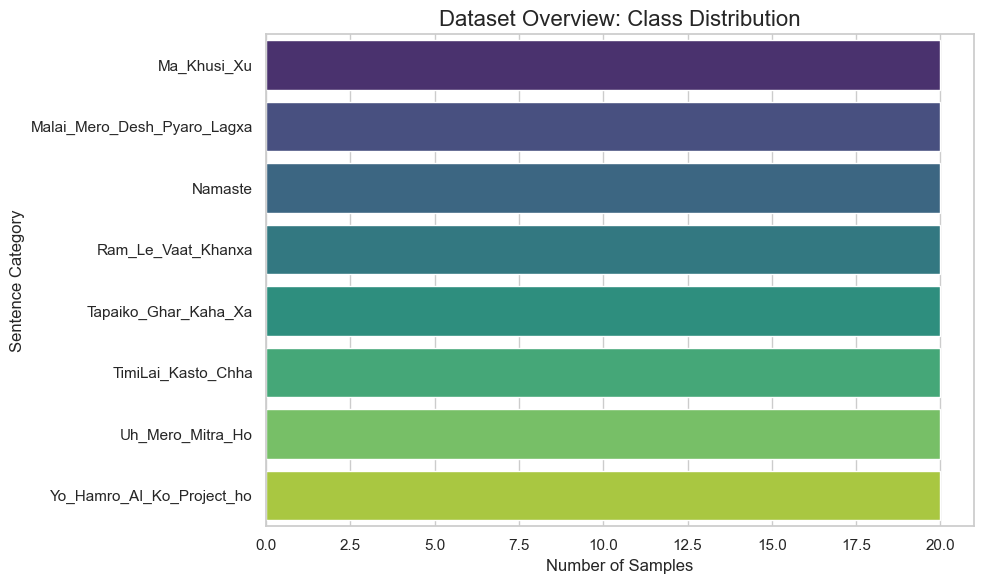

In [14]:
# Load Y.npy to see the class distribution
Y_raw = np.load(os.path.join(PROCESSED_DATA_PATH, 'Y.npy'))

plt.figure(figsize=(10, 6))
sns.countplot(y=Y_raw, palette="viridis", order=np.unique(Y_raw))
plt.title('Dataset Overview: Class Distribution', fontsize=16)
plt.xlabel('Number of Samples', fontsize=12)
plt.ylabel('Sentence Category', fontsize=12)
plt.tight_layout()
plt.show()

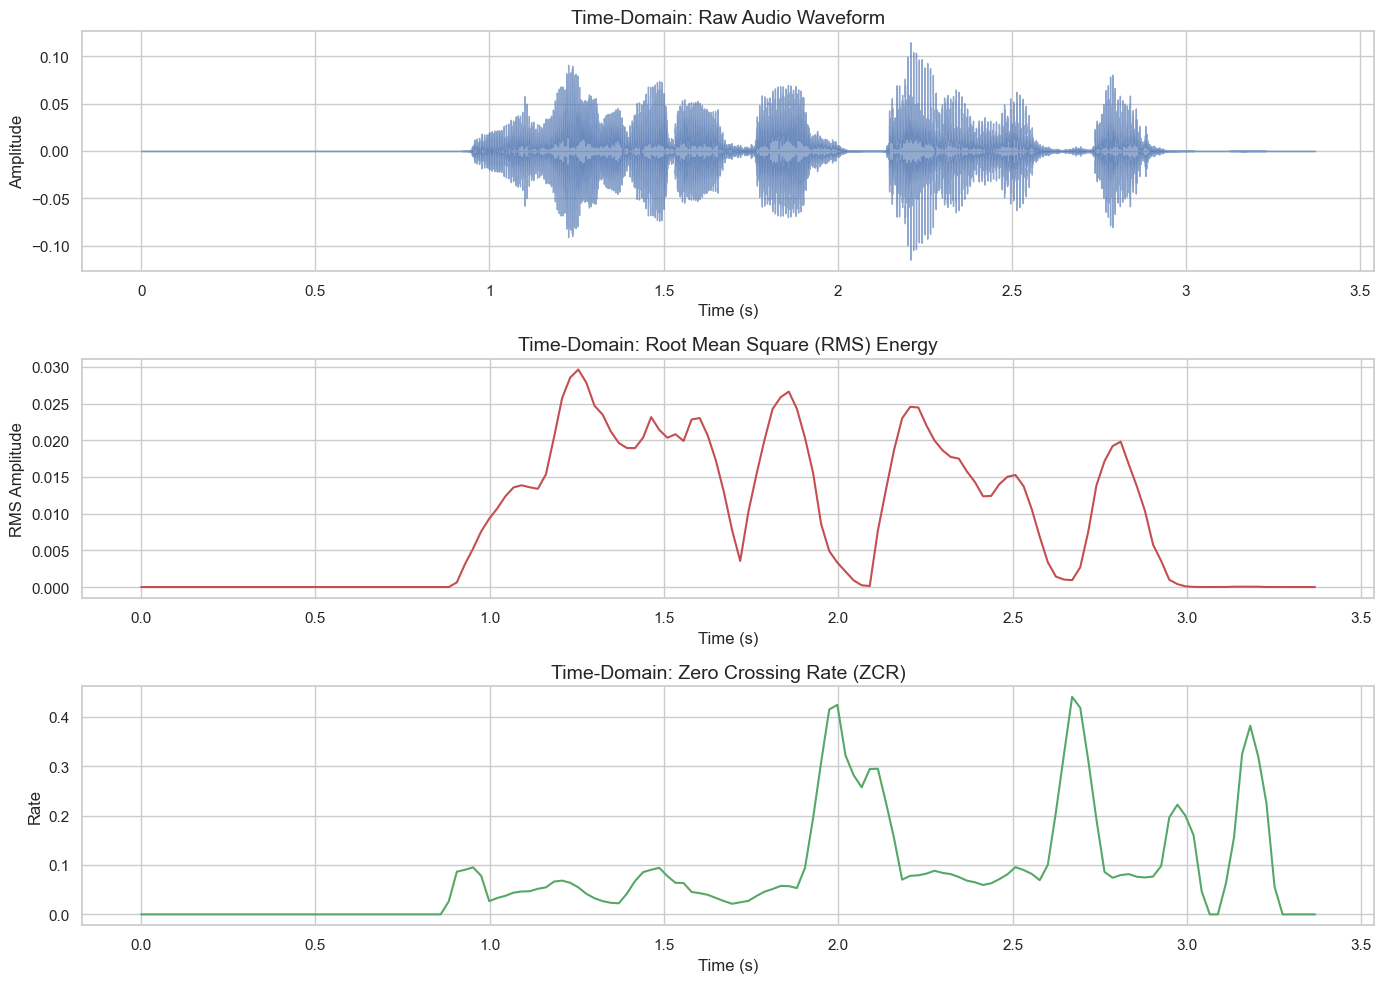

In [19]:
# Load a sample audio file
SAMPLE_AUDIO_PATH="/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/data/raw/Malai_Mero_Desh_Pyaro_Lagxa/spk01_s02.wav"
audio, sr = librosa.load(SAMPLE_AUDIO_PATH, sr=22050)

plt.figure(figsize=(14, 10))

# 1. Raw Audio Waveform
plt.subplot(3, 1, 1)
librosa.display.waveshow(audio, sr=sr, alpha=0.6)
plt.title('Time-Domain: Raw Audio Waveform', fontsize=14)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

# 2. RMS Energy
rms = librosa.feature.rms(y=audio, frame_length=2048, hop_length=512)[0]
frames = range(len(rms))
t = librosa.frames_to_time(frames, hop_length=512, sr=sr)
plt.subplot(3, 1, 2)
plt.plot(t, rms, color='r')
plt.title('Time-Domain: Root Mean Square (RMS) Energy', fontsize=14)
plt.xlabel('Time (s)')
plt.ylabel('RMS Amplitude')

# 3. Zero Crossing Rate (ZCR)
zcr = librosa.feature.zero_crossing_rate(y=audio, frame_length=2048, hop_length=512)[0]
plt.subplot(3, 1, 3)
plt.plot(t, zcr, color='g')
plt.title('Time-Domain: Zero Crossing Rate (ZCR)', fontsize=14)
plt.xlabel('Time (s)')
plt.ylabel('Rate')

plt.tight_layout()
plt.show()

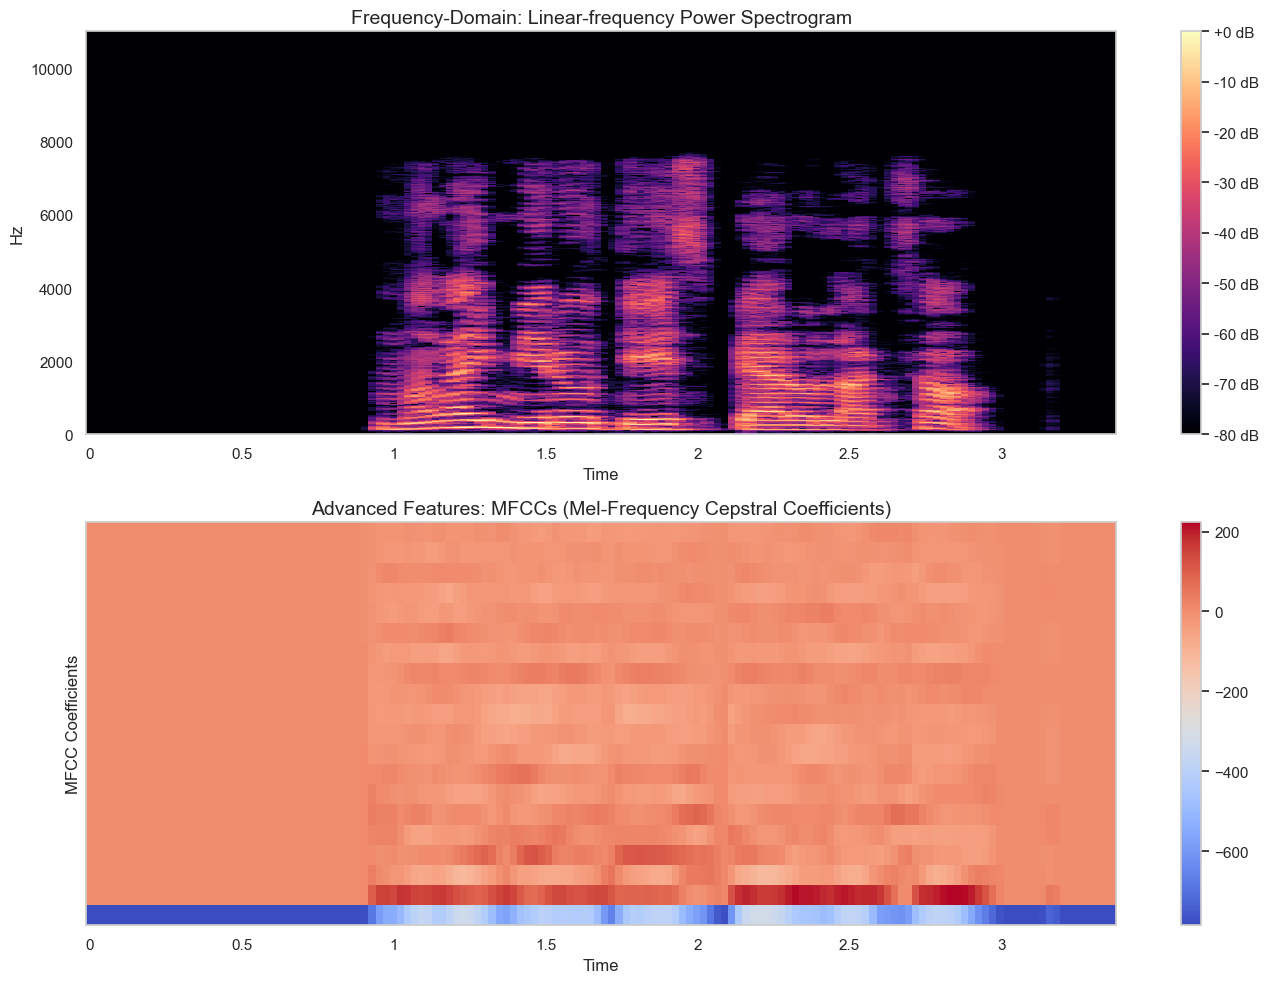

In [20]:
plt.figure(figsize=(14, 10))

# 1. Spectrogram (Frequency Domain)
# Convert to decibels for better visualization
D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
plt.subplot(2, 1, 1)
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Frequency-Domain: Linear-frequency Power Spectrogram', fontsize=14)

# 2. Mel-Frequency Cepstral Coefficients (MFCCs - Advanced Features)
# Note: Using n_mfcc=20 to match your data_prep.py default
mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20, n_fft=2048, hop_length=512)
plt.subplot(2, 1, 2)
librosa.display.specshow(mfccs, sr=sr, x_axis='time')
plt.colorbar()
plt.title('Advanced Features: MFCCs (Mel-Frequency Cepstral Coefficients)', fontsize=14)
plt.ylabel('MFCC Coefficients')

plt.tight_layout()
plt.show()

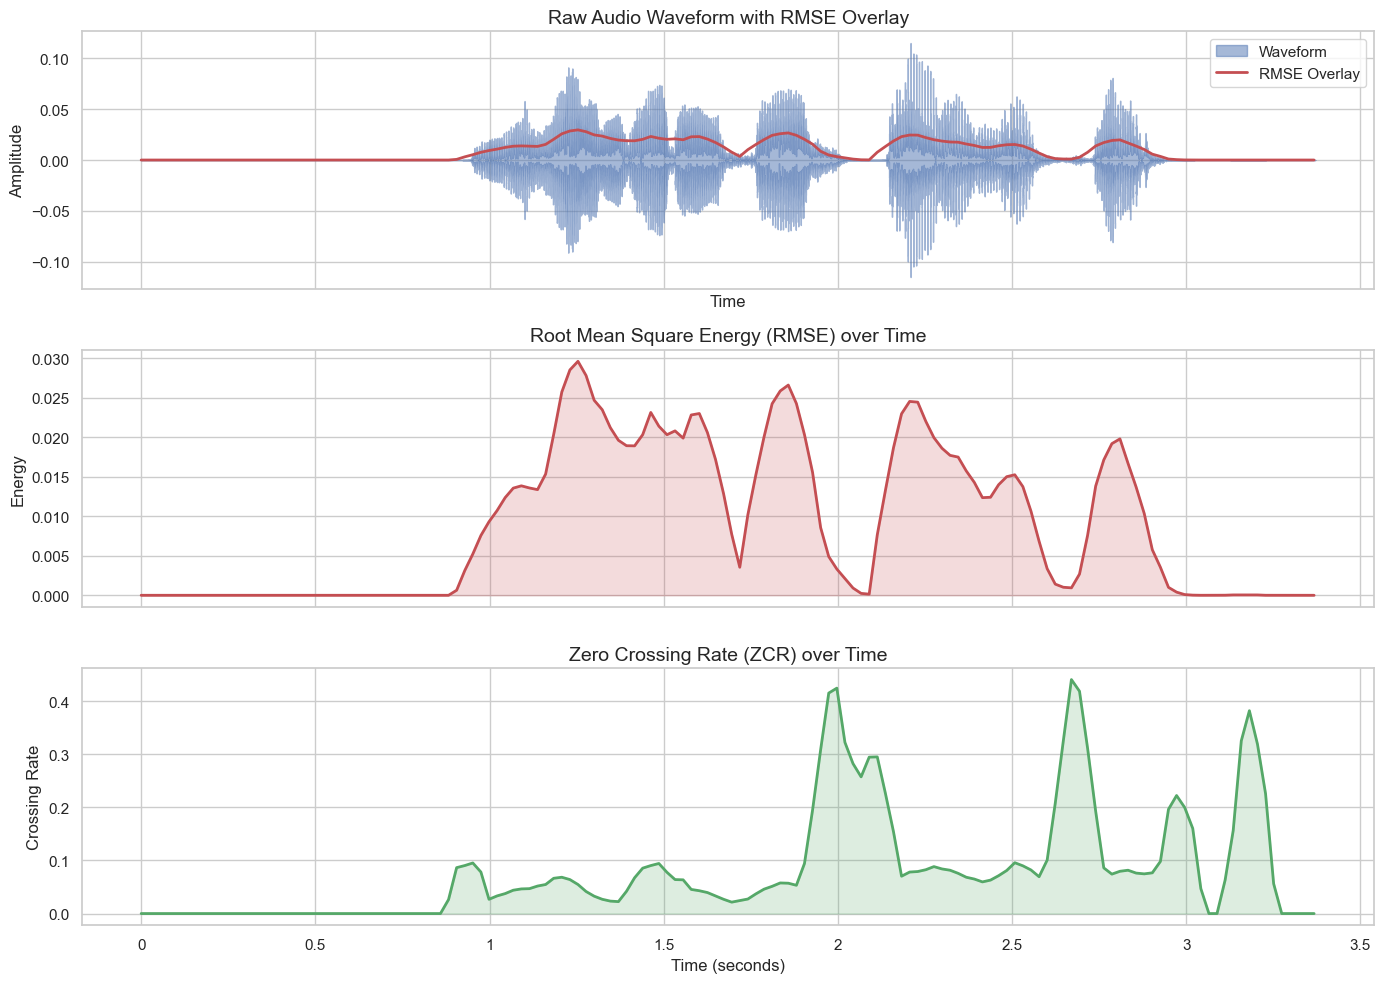

In [30]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# --- Parameters from your data_prep.py ---
FRAME_LENGTH = 2048
HOP_LENGTH = 512

# 1. Load the audio file
SAMPLE_AUDIO_PATH="/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/data/raw/Malai_Mero_Desh_Pyaro_Lagxa/spk01_s02.wav"

audio, sr = librosa.load(SAMPLE_AUDIO_PATH, sr=22050)

# 2. Extract Features (RMSE and ZCR)
# Using [0] to squeeze the array from 2D to 1D for plotting
rmse_val = librosa.feature.rms(y=audio, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
zcr_val = librosa.feature.zero_crossing_rate(y=audio, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]

# 3. Create a time array for the features so they align perfectly with the audio length
frames = range(len(rmse_val))
time_axis = librosa.frames_to_time(frames, hop_length=HOP_LENGTH, sr=sr)

# --- Plotting ---
fig, ax = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot A: Raw Waveform with RMSE overlay
librosa.display.waveshow(audio, sr=sr, ax=ax[0], alpha=0.5, label='Waveform')
ax[0].plot(time_axis, rmse_val, color='r', label='RMSE Overlay', lw=2)
ax[0].set_title('Raw Audio Waveform with RMSE Overlay', fontsize=14)
ax[0].set_ylabel('Amplitude')
ax[0].legend(loc='upper right')

# Plot B: RMSE (Standalone)
ax[1].plot(time_axis, rmse_val, color='r', lw=2)
ax[1].set_title('Root Mean Square Energy (RMSE) over Time', fontsize=14)
ax[1].set_ylabel('Energy')
ax[1].fill_between(time_axis, rmse_val, color='r', alpha=0.2) # Fills the area under the curve

# Plot C: ZCR (Standalone)
ax[2].plot(time_axis, zcr_val, color='g', lw=2)
ax[2].set_title('Zero Crossing Rate (ZCR) over Time', fontsize=14)
ax[2].set_xlabel('Time (seconds)', fontsize=12)
ax[2].set_ylabel('Crossing Rate')
ax[2].fill_between(time_axis, zcr_val, color='g', alpha=0.2)

plt.tight_layout()
plt.show()

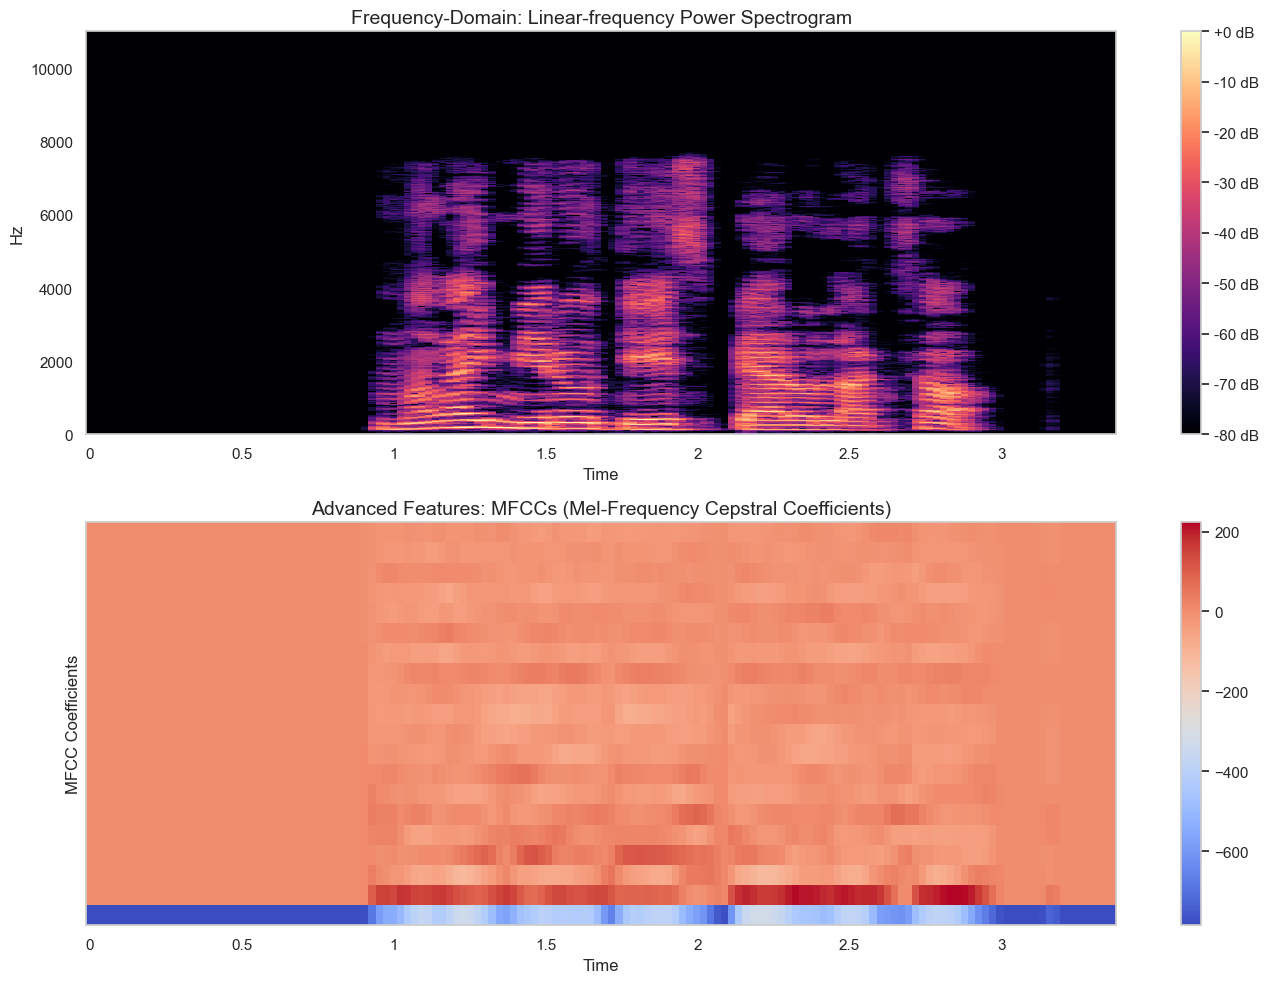

In [21]:
plt.figure(figsize=(14, 10))

# 1. Spectrogram (Frequency Domain)
# Convert to decibels for better visualization
D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
plt.subplot(2, 1, 1)
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Frequency-Domain: Linear-frequency Power Spectrogram', fontsize=14)

# 2. Mel-Frequency Cepstral Coefficients (MFCCs - Advanced Features)
# Note: Using n_mfcc=20 to match your data_prep.py default
mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20, n_fft=2048, hop_length=512)
plt.subplot(2, 1, 2)
librosa.display.specshow(mfccs, sr=sr, x_axis='time')
plt.colorbar()
plt.title('Advanced Features: MFCCs (Mel-Frequency Cepstral Coefficients)', fontsize=14)
plt.ylabel('MFCC Coefficients')

plt.tight_layout()
plt.show()

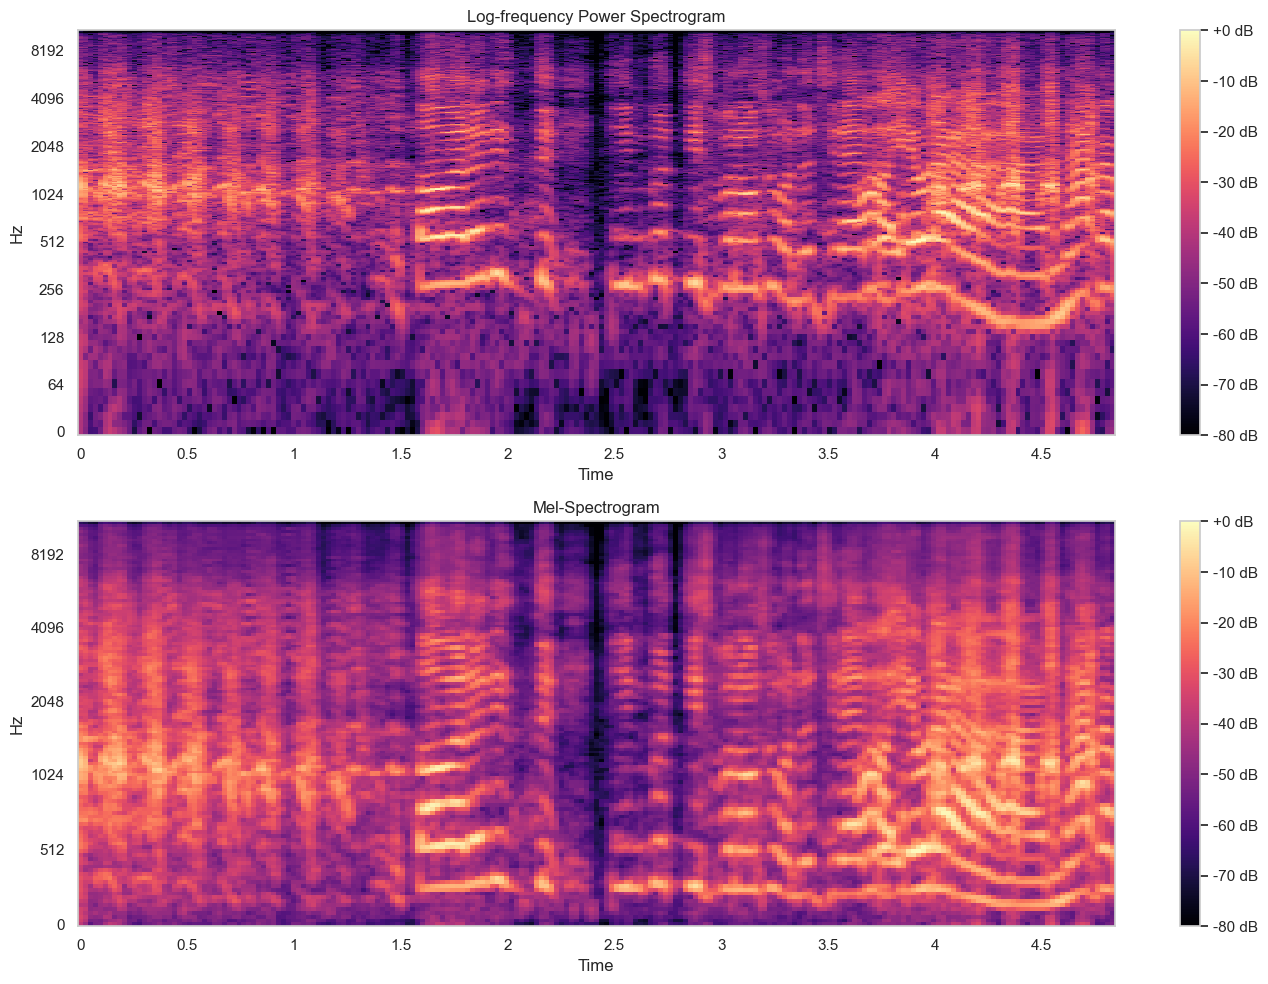

In [5]:
# Cell 5: Spectrogram & Mel-Spectrogram
fig, ax = plt.subplots(2, 1, figsize=(14, 10))

# 1. Standard Spectrogram (STFT)
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
img1 = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log', ax=ax[0])
fig.colorbar(img1, ax=ax[0], format="%+2.0f dB")
ax[0].set_title('Log-frequency Power Spectrogram')

# 2. Mel-Spectrogram
M = librosa.feature.melspectrogram(y=y, sr=sr)
M_db = librosa.power_to_db(M, ref=np.max)
img2 = librosa.display.specshow(M_db, sr=sr, x_axis='time', y_axis='mel', ax=ax[1])
fig.colorbar(img2, ax=ax[1], format="%+2.0f dB")
ax[1].set_title('Mel-Spectrogram')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/.venv-1/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/.venv-1/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


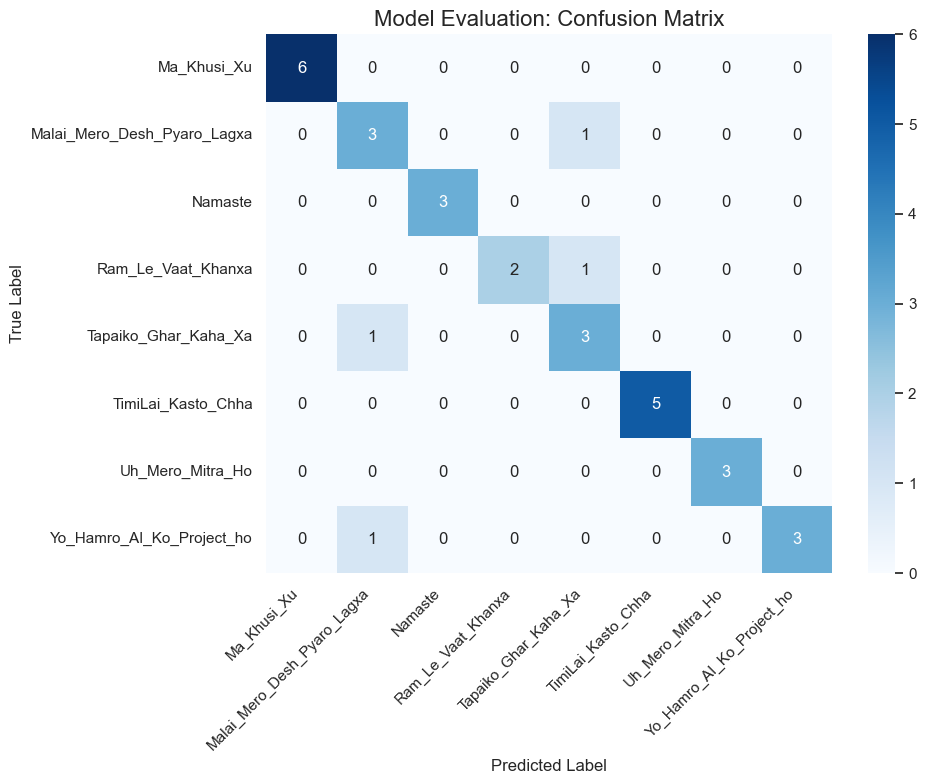


Classification Report:

                             precision    recall  f1-score   support

                Ma_Khusi_Xu       1.00      1.00      1.00         6
Malai_Mero_Desh_Pyaro_Lagxa       0.60      0.75      0.67         4
                    Namaste       1.00      1.00      1.00         3
         Ram_Le_Vaat_Khanxa       1.00      0.67      0.80         3
       Tapaiko_Ghar_Kaha_Xa       0.60      0.75      0.67         4
         TimiLai_Kasto_Chha       1.00      1.00      1.00         5
           Uh_Mero_Mitra_Ho       1.00      1.00      1.00         3
  Yo_Hamro_AI_Ko_Project_ho       1.00      0.75      0.86         4

                   accuracy                           0.88        32
                  macro avg       0.90      0.86      0.87        32
               weighted avg       0.90      0.88      0.88        32



In [27]:
# Load artifacts
model = load_model("/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/models/nepali_asr_model.h5")
scaler = joblib.load("/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/models/scaler.joblib")
le = joblib.load("/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/models/label_encoder.joblib")

# Re-split the data exactly as in training to get the test set
X = np.load(os.path.join(PROCESSED_DATA_PATH, 'X.npy'))
Y = np.load(os.path.join(PROCESSED_DATA_PATH, 'Y.npy'))

if len(X.shape) == 3:
    X = X.reshape(X.shape[0], -1)

X_scaled = scaler.transform(X) # Scale using loaded scaler
Y_encoded = le.transform(Y)

# Use random_state=42 to ensure you get the exact same test set as train.py
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y_encoded, test_size=0.2, random_state=42)

# Make Predictions
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Generate Confusion Matrix
cm = confusion_matrix(Y_test, y_pred_classes)
class_names = le.classes_

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Model Evaluation: Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print Classification Report
print("\nClassification Report:\n")
print(classification_report(Y_test, y_pred_classes, target_names=class_names))